# Loan Prediction

# Libraries Imported

In [247]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV
from sklearn.metrics import classification_report

from imblearn.over_sampling import RandomOverSampler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

# DataSet Import

In [248]:
df = pd.read_csv(r"C:\PRGM\luminar\machine learning\DataSet\loan_data.csv")
df 

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,LP002953,Male,Yes,3+,Graduate,No,5703,0.0,128.0,360.0,1.0,Urban,Y
377,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
378,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
379,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y


* Dataset contains 381 rows and 13 columns.

In [249]:
df.drop(columns=["Loan_ID"],inplace=True)

* Loan ID isn't a required feature for prediction. 

# DataSet Study

In [250]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             376 non-null    object 
 1   Married            381 non-null    object 
 2   Dependents         373 non-null    object 
 3   Education          381 non-null    object 
 4   Self_Employed      360 non-null    object 
 5   ApplicantIncome    381 non-null    int64  
 6   CoapplicantIncome  381 non-null    float64
 7   LoanAmount         381 non-null    float64
 8   Loan_Amount_Term   370 non-null    float64
 9   Credit_History     351 non-null    float64
 10  Property_Area      381 non-null    object 
 11  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 35.8+ KB


* There are presence of null values.
* There are 7 object columns, 1 integer & 4 float.

In [251]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


* Co-Applicant's max income is greater than Applicant's Income.
* Credit History is mostly 1.

In [252]:
df.isna().sum()

Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

* Gender, Self_Employed, Loan_Amount_Term, Credit_History have null values

In [253]:
nan_cols = ["Gender","Dependents","Self_Employed","Loan_Amount_Term","Credit_History"]

for i in nan_cols:
    print(df[i].value_counts())
    print()

Gender
Male      291
Female     85
Name: count, dtype: int64

Dependents
0     234
2      59
1      52
3+     28
Name: count, dtype: int64

Self_Employed
No     325
Yes     35
Name: count, dtype: int64

Loan_Amount_Term
360.0    312
180.0     29
480.0     11
300.0      7
120.0      3
84.0       3
240.0      2
60.0       1
12.0       1
36.0       1
Name: count, dtype: int64

Credit_History
1.0    294
0.0     57
Name: count, dtype: int64



* Dependents need to be converted into int.

# Correlation

<Axes: >

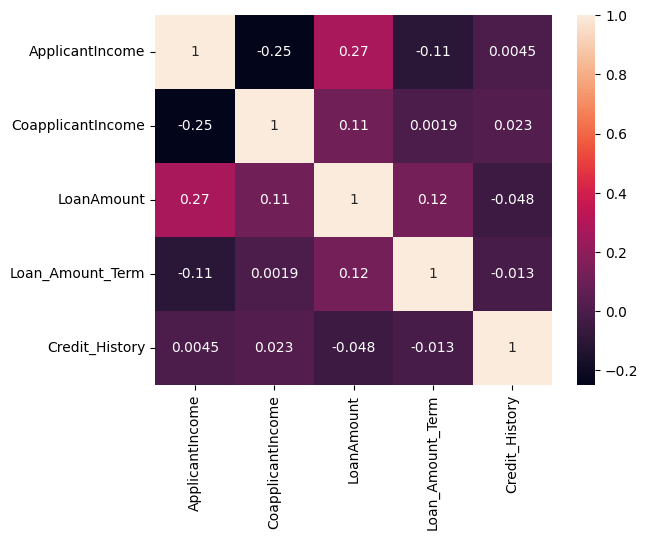

In [254]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

* they are not having a good correlation.

# Missing Value Handling

In [255]:
df_nan_handled = df.copy()
df_nan_handled.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [256]:
for i in nan_cols:
    df_nan_handled[i] = df_nan_handled[i].fillna(df_nan_handled[i].mode()[0])

* Filled the null values with their mode values.

In [257]:
df_nan_handled.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

# Data Type Conversion

In [258]:
df_nan_handled["Dependents"] = df_nan_handled["Dependents"].replace("3+","3")
df_nan_handled["Dependents"] = df_nan_handled["Dependents"].astype("int")

* Replaced 3+ with 3 and converted the type to int.

# Outlier Handling

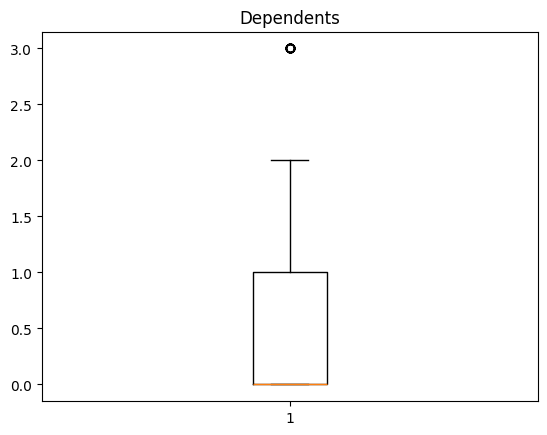

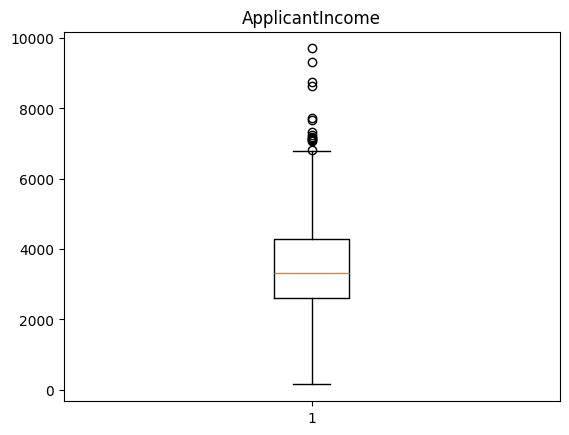

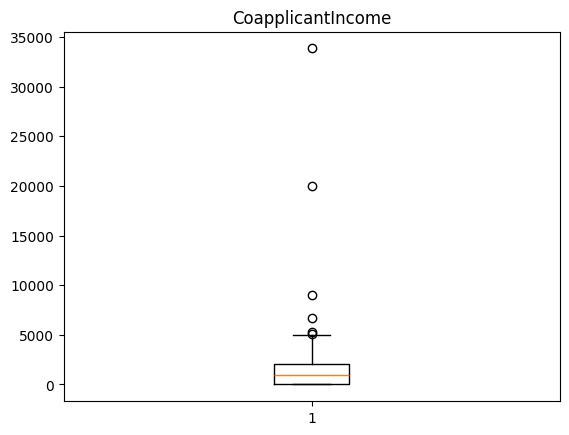

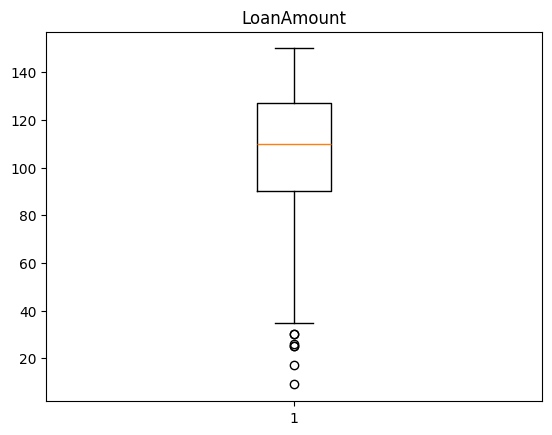

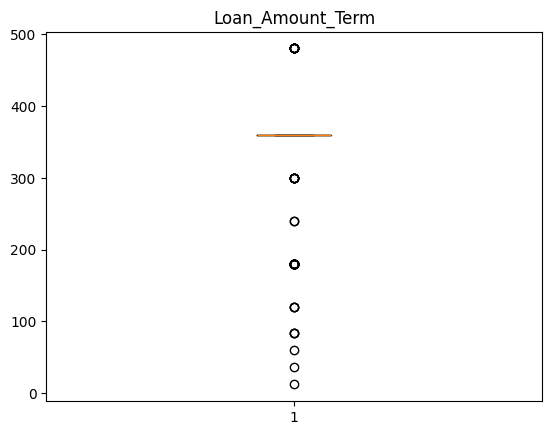

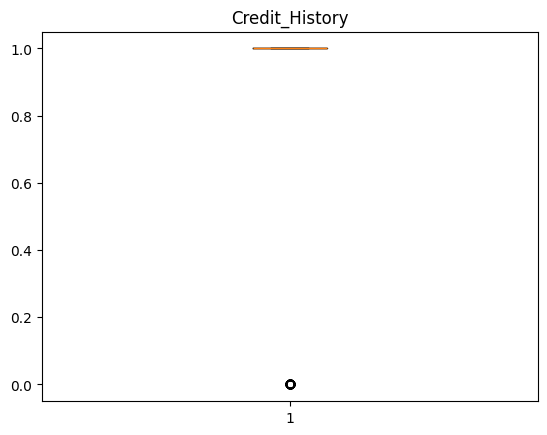

In [259]:
df_outlier_handled = df_nan_handled.copy()

for i in df:
    if df_outlier_handled[i].dtype != "object":
        plt.boxplot(df_outlier_handled[i])
        plt.title(i)
        plt.show()
        print()

* Outliers are present but the one that requires more attention is the Co-Applicant's income.

In [260]:
df_outlier_handled = df_outlier_handled[df_outlier_handled["CoapplicantIncome"]<10000]

* Co-Applicant income is limited under 10000

# Encoding

In [261]:
df_encoded = df_outlier_handled.copy()
df_encoded

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
376,Male,Yes,3,Graduate,No,5703,0.0,128.0,360.0,1.0,Urban,Y
377,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
378,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
379,Male,Yes,3,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y


Unique Values Checking

In [262]:
for i in df_encoded:
    if df_encoded[i].dtype == "object":
        print(df_encoded[i].value_counts())
        print()

Gender
Male      294
Female     85
Name: count, dtype: int64

Married
Yes    228
No     151
Name: count, dtype: int64

Education
Graduate        276
Not Graduate    103
Name: count, dtype: int64

Self_Employed
No     344
Yes     35
Name: count, dtype: int64

Property_Area
Semiurban    148
Urban        125
Rural        106
Name: count, dtype: int64

Loan_Status
Y    270
N    109
Name: count, dtype: int64



* Since the Categories of the object columns are less and some have hierarchy we will use Label and Ordinal Encoding.

Label and Ordinal Classification

In [263]:
label = ["Gender","Married","Self_Employed","Loan_Status"]
ordinal = ["Education","Property_Area"]

Label Encoding

In [264]:
dit_labels = {}
for i in label:
    dit_labels[i] = LabelEncoder()
    df_encoded[i] = dit_labels[i].fit_transform(df_encoded[i])

Ordinal Encoding

In [265]:
ord_education = OrdinalEncoder(categories=[["Not Graduate","Graduate"]])
df_encoded["Education"] = ord_education.fit_transform(df_encoded[["Education"]])

ord_property = OrdinalEncoder(categories=[["Rural","Semiurban","Urban"]])
df_encoded["Property_Area"] = ord_property.fit_transform(df_encoded[["Property_Area"]])

Encoded Result

In [266]:
df_encoded

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,1,1,1.0,0,4583,1508.0,128.0,360.0,1.0,0.0,0
1,1,1,0,1.0,1,3000,0.0,66.0,360.0,1.0,2.0,1
2,1,1,0,0.0,0,2583,2358.0,120.0,360.0,1.0,2.0,1
3,1,0,0,1.0,0,6000,0.0,141.0,360.0,1.0,2.0,1
4,1,1,0,0.0,0,2333,1516.0,95.0,360.0,1.0,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
376,1,1,3,1.0,0,5703,0.0,128.0,360.0,1.0,2.0,1
377,1,1,0,1.0,0,3232,1950.0,108.0,360.0,1.0,0.0,1
378,0,0,0,1.0,0,2900,0.0,71.0,360.0,1.0,0.0,1
379,1,1,3,1.0,0,4106,0.0,40.0,180.0,1.0,0.0,1


In [267]:
df_encoded = df_encoded.astype("int")

* Converted into int since there are no point values.

In [268]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 379 entries, 0 to 380
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Gender             379 non-null    int64
 1   Married            379 non-null    int64
 2   Dependents         379 non-null    int64
 3   Education          379 non-null    int64
 4   Self_Employed      379 non-null    int64
 5   ApplicantIncome    379 non-null    int64
 6   CoapplicantIncome  379 non-null    int64
 7   LoanAmount         379 non-null    int64
 8   Loan_Amount_Term   379 non-null    int64
 9   Credit_History     379 non-null    int64
 10  Property_Area      379 non-null    int64
 11  Loan_Status        379 non-null    int64
dtypes: int64(12)
memory usage: 38.5 KB


# Correlation Check

<Axes: >

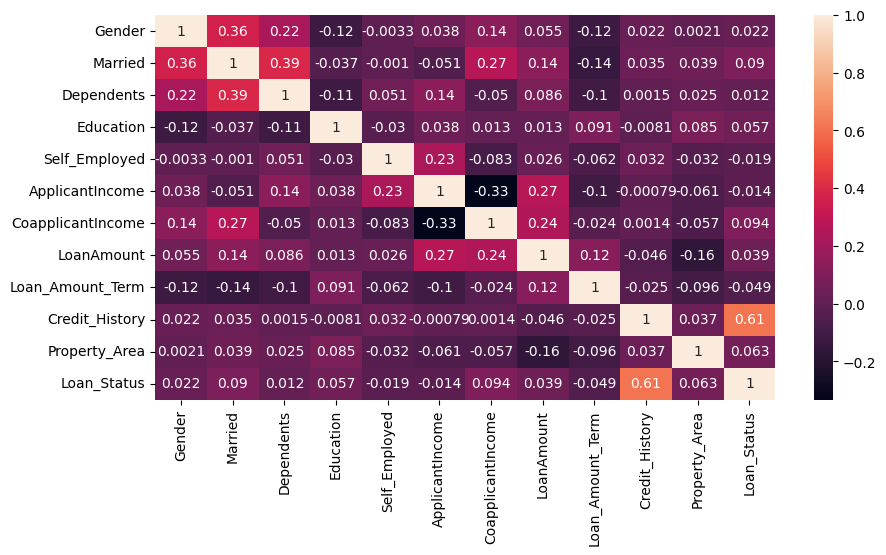

In [269]:
plt.figure(figsize=(10,5))
sns.heatmap(df_encoded.corr(numeric_only=True),annot=True)

* Correlation of the Columns are bad & the Loan Status is highly dependant on Credit History.

# Features(x) And Label(y)

In [270]:
x = df_encoded.drop(columns=["Loan_Status","Credit_History"])
y = df_encoded["Loan_Status"]
x.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Property_Area'],
      dtype='object')

* Dropped Credit History since the result was only dependant on this alone. 

# Imbalance Handling

In [271]:
ros = RandomOverSampler()
x_res,y_res = ros.fit_resample(x,y)

y_res.value_counts()

Loan_Status
0    270
1    270
Name: count, dtype: int64

* Output Data Balanced.

# Features Scaling

In [272]:
mms = MinMaxScaler()
x_scaled = mms.fit_transform(x_res)
x_scaled

array([[1.        , 1.        , 0.33333333, ..., 0.84397163, 0.74358974,
        0.        ],
       [1.        , 1.        , 0.        , ..., 0.40425532, 0.74358974,
        1.        ],
       [1.        , 1.        , 0.        , ..., 0.78723404, 0.74358974,
        1.        ],
       ...,
       [1.        , 1.        , 0.33333333, ..., 0.40425532, 0.61538462,
        0.        ],
       [1.        , 1.        , 0.33333333, ..., 0.71631206, 0.74358974,
        1.        ],
       [1.        , 1.        , 0.66666667, ..., 0.83687943, 0.74358974,
        0.5       ]], shape=(540, 10))

* Scaling to set the features into similar Values.

# Train & Test Data

In [273]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_res, test_size=0.2, random_state=40)

* Split the Model for training & testing.

# Model Selection

In [274]:
models = [KNeighborsClassifier(),SVC(),GaussianNB(),DecisionTreeClassifier()]

for i in models:
    print(i)
    model = i.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print("Cross Validation Score: ",cross_val_score(model,x_train,y_train,cv=5).mean())
    print()

KNeighborsClassifier()
Cross Validation Score:  0.5879443998930768

SVC()
Cross Validation Score:  0.5509222133119487

GaussianNB()
Cross Validation Score:  0.5579256883186314

DecisionTreeClassifier()
Cross Validation Score:  0.7593156909917135



Model Best Results:
* Before outlier handling: SVM gives the best result i.e 86% 
* After outlier handling: Naive Bayes GaussianNB gives the best result i.e 84%
* After removing Credit History: Decision Tree with 78% accuracy

# Ensemble Model Training

In [275]:
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(x_train,y_train)
y_pred = rfc.predict(x_test)
print(classification_report(y_test,y_pred))
print(cross_val_score(rfc,x_train,y_train).mean())
cross_val_score(rfc,x_train,y_train).mean()

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        56
           1       0.94      0.90      0.92        52

    accuracy                           0.93       108
   macro avg       0.93      0.93      0.93       108
weighted avg       0.93      0.93      0.93       108

0.7986634589681904


np.float64(0.8079123229083134)

* Gives nearly 80% Accuracy

In [276]:
gbc = GradientBoostingClassifier(learning_rate=0.1,n_estimators=500)
gbc.fit(x_train,y_train)
y_pred = gbc.predict(x_test)
print(classification_report(y_test,y_pred))
print(cross_val_score(gbc,x_train,y_train).mean())
cross_val_score(gbc,x_train,y_train).mean()

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        56
           1       0.96      0.87      0.91        52

    accuracy                           0.92       108
   macro avg       0.92      0.91      0.92       108
weighted avg       0.92      0.92      0.92       108

0.8079123229083134


np.float64(0.810211173483026)

* Gradient Boosting Slightly gives more result.

# HyperParameter Tuning

* We will choose Gradient Boosting for HyperParameter Tuning because of its better results.

Gradient Boosting 

In [280]:
params = {"n_estimators":[50,100,200],"learning_rate":[0.001,0.1,0.2],"max_depth":[3,5,10],"subsample":[0.7,0.8,1.0],"min_samples_split":[2,5,10]}

rsv = RandomizedSearchCV(gbc,params,cv=5,scoring="accuracy")
rsv.fit(x_train,y_train)

gsv = GridSearchCV(gbc,params,cv=5,scoring="accuracy")
gsv.fit(x_train,y_train)


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(n_estimators=500),
             param_grid={'learning_rate': [0.001, 0.1, 0.2],
                         'max_depth': [3, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200],
                         'subsample': [0.7, 0.8, 1.0]},
             scoring='accuracy')

In [281]:
print("Gradient Boosting Randomized Search")
print(rsv.best_estimator_)
print(rsv.best_score_)
print()
print("Gradient Boosting Grid Search")
print(gsv.best_estimator_)
print(gsv.best_score_)

Gradient Boosting Randomized Search
GradientBoostingClassifier(learning_rate=0.001, max_depth=10, n_estimators=50,
                           subsample=0.8)
0.8263833199679229

Gradient Boosting Grid Search
GradientBoostingClassifier(learning_rate=0.2, max_depth=10, min_samples_split=5,
                           n_estimators=200, subsample=0.8)
0.8425821972734564


* GridSearchCV on GradientBoost provided us with best result i.e 84%.
* Took 8:05 min for training.
* Best Params: GradientBoostingClassifier(learning_rate=0.2, max_depth=10, min_samples_split=5, n_estimators=200, subsample=0.8)

# Finalized Model 

In [ ]:
gbc = GradientBoostingClassifier(learning_rate=0.2,max_depth=10,min_samples_split=5,n_estimators=200,subsample=0.8)
gbc.fit(x_train,y_train)
y_pred = gbc.predict(x_test)
print(classification_report(y_test,y_pred))
print(cross_val_score(gbc,x_train,y_train).mean())

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        56
           1       0.94      0.92      0.93        52

    accuracy                           0.94       108
   macro avg       0.94      0.93      0.94       108
weighted avg       0.94      0.94      0.94       108

0.8380379577653032


np.float64(0.8333867949746058)

# Export Requirements:
* model = gbc
* scaler = mms
* label = dit_labels
* education = ord_education 
* property = ord_property

# Pickling

In [301]:
dit = {"model":gbc,"scaler":mms,"label":dit_labels,"education":ord_education,"property":ord_property}

with open("Loan_Prediction_Model.pkl","wb") as f:
    pickle.dump(dit,f)